# Лабораторная работа №4
## Линейные модели, SVM и деревья решений

**Дисциплина:** Технологии машинного обучения

**Цель работы:** изучение линейных моделей, SVM и деревьев решений на одной задаче классификации.

**Состав работы:**
1. Выбор и описание датасета.
2. Предобработка и разделение на train/test.
3. Обучение логистической регрессии, SVM и дерева решений.
4. Оценка качества по двум метрикам и сравнение моделей.
5. График важности признаков в дереве решений.
6. Визуализация дерева решений и вывод правил в текстовом виде.

## 1. Описание набора данных

Используется датасет **Breast Cancer Wisconsin (Diagnostic)** из `scikit-learn` ([load_breast_cancer](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)).

**Размер:** 569 наблюдений, 30 числовых признаков, бинарная целевая переменная (0 — `malignant` / злокачественная, 1 — `benign` / доброкачественная). Пропусков нет.

**Признаки** — 10 базовых характеристик опухоли (`radius`, `texture`, `perimeter`, `area`, `smoothness`, `compactness`, `concavity`, `concave points`, `symmetry`, `fractal dimension`), для каждой из которых посчитаны среднее (`mean`), стандартная ошибка (`error`) и худшее значение (`worst`).

**Задача:** бинарная классификация. В рамках работы будут сравниваться три модели: логистическая регрессия, SVM и дерево решений.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay
)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

In [2]:
raw = load_breast_cancer(as_frame=True)
df = raw.frame
FEATURES = list(raw.feature_names)
TARGET = 'target'
CLASSES = list(raw.target_names)

print(f'Размер датасета: {df.shape[0]} наблюдений, {len(FEATURES)} признаков')
print(f'Классы: {CLASSES} (0={CLASSES[0]}, 1={CLASSES[1]})')
df.head()

Размер датасета: 569 наблюдений, 30 признаков
Классы: [np.str_('malignant'), np.str_('benign')] (0=malignant, 1=benign)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
class_counts = df[TARGET].value_counts().sort_index()
class_counts.index = [CLASSES[i] for i in class_counts.index]
print('Распределение классов:')
print(class_counts)
print(f'Доля положительного класса: {df[TARGET].mean():.3f}')
print(f'Пропусков в датасете: {df.isna().sum().sum()}')

Распределение классов:
malignant    212
benign       357
Name: count, dtype: int64
Доля положительного класса: 0.627
Пропусков в датасете: 0


Лёгкий дисбаланс (~63% benign, ~37% malignant), но не критический — будем использовать стратифицированное разбиение.

## 2. Предобработка и разделение выборки

Пропусков и категориальных признаков нет, поэтому подготовка сводится к двум шагам:
1. Стратифицированное разбиение 75/25 через `train_test_split`.
2. Масштабирование `StandardScaler` (нужно для логистической регрессии и особенно для SVM; дерево решений к масштабу нечувствительно — для него будем использовать неотмасштабированные данные).

In [4]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Доля положительного класса в train: {y_train.mean():.3f}, в test: {y_test.mean():.3f}')

Train: (426, 30), Test: (143, 30)
Доля положительного класса в train: 0.627, в test: 0.629


## 3. Обучение моделей

Для каждой модели сохраним вероятности положительного класса — они понадобятся для ROC AUC и ROC-кривых.

**Метрики:** в качестве двух оценок качества возьмём `accuracy` (доля правильных) и `ROC AUC` (площадь под ROC-кривой, устойчива к дисбалансу). Дополнительно посмотрим F1 и подробный classification report.

### 3.1. Логистическая регрессия

In [5]:
logreg = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
logreg.fit(X_train_sc, y_train)

y_pred_lr = logreg.predict(X_test_sc)
y_proba_lr = logreg.predict_proba(X_test_sc)[:, 1]

print(f'Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'ROC AUC:   {roc_auc_score(y_test, y_proba_lr):.4f}')
print(f'F1:        {f1_score(y_test, y_pred_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=CLASSES))

Accuracy:  0.9860
ROC AUC:   0.9977
F1:        0.9889

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



### 3.2. SVM (RBF-ядро)

In [6]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE)
svm.fit(X_train_sc, y_train)

y_pred_svm = svm.predict(X_test_sc)
y_proba_svm = svm.predict_proba(X_test_sc)[:, 1]

print(f'Accuracy:  {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'ROC AUC:   {roc_auc_score(y_test, y_proba_svm):.4f}')
print(f'F1:        {f1_score(y_test, y_pred_svm):.4f}')
print()
print(classification_report(y_test, y_pred_svm, target_names=CLASSES))

Accuracy:  0.9790
ROC AUC:   0.9969
F1:        0.9832

              precision    recall  f1-score   support

   malignant       0.96      0.98      0.97        53
      benign       0.99      0.98      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



### 3.3. Дерево решений

Чтобы дерево было читаемым при визуализации, ограничим глубину `max_depth=4`. Деревьям масштабирование не нужно, поэтому подаём исходные признаки.

In [7]:
tree = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
y_proba_tree = tree.predict_proba(X_test)[:, 1]

print(f'Accuracy:  {accuracy_score(y_test, y_pred_tree):.4f}')
print(f'ROC AUC:   {roc_auc_score(y_test, y_proba_tree):.4f}')
print(f'F1:        {f1_score(y_test, y_pred_tree):.4f}')
print()
print(classification_report(y_test, y_pred_tree, target_names=CLASSES))

Accuracy:  0.9441
ROC AUC:   0.9384
F1:        0.9556

              precision    recall  f1-score   support

   malignant       0.92      0.92      0.92        53
      benign       0.96      0.96      0.96        90

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143



## 4. Сравнение моделей

Сводим метрики в одну таблицу и визуализируем матрицы ошибок и ROC-кривые.

In [8]:
results = pd.DataFrame({
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_tree),
    ],
    'ROC AUC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_svm),
        roc_auc_score(y_test, y_proba_tree),
    ],
    'F1': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_tree),
    ],
}, index=['LogReg', 'SVM (RBF)', 'DecisionTree'])
results.round(4)

,Accuracy,ROC AUC,F1
LogReg,0.9860,0.9977,0.9889
SVM (RBF),0.9790,0.9969,0.9832
DecisionTree,0.9441,0.9384,0.9556


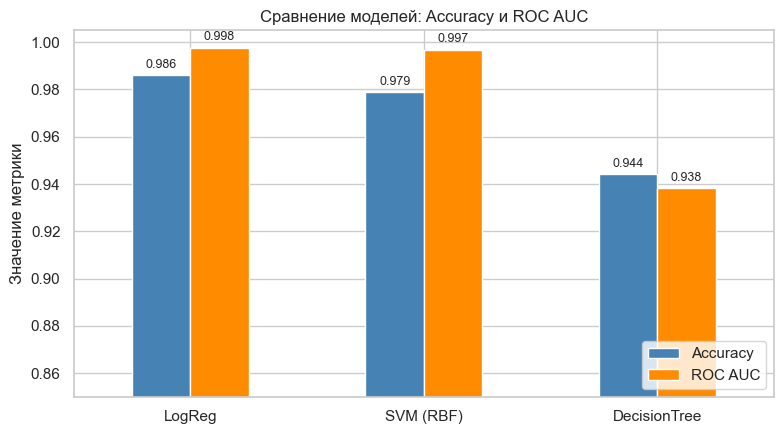

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
results[['Accuracy', 'ROC AUC']].plot(kind='bar', ax=ax, color=['steelblue', 'darkorange'])
ax.set_ylim(0.85, 1.005)
ax.set_title('Сравнение моделей: Accuracy и ROC AUC')
ax.set_ylabel('Значение метрики')
ax.set_xticklabels(results.index, rotation=0)
ax.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

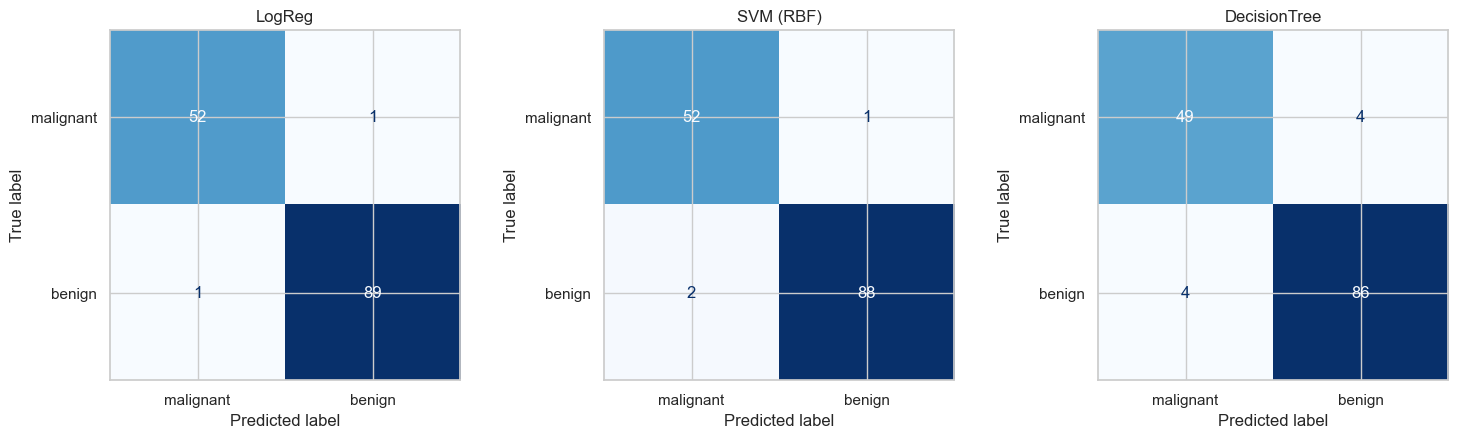

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, y_pred) in zip(axes, [
    ('LogReg', y_pred_lr),
    ('SVM (RBF)', y_pred_svm),
    ('DecisionTree', y_pred_tree),
]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='d'
    )
    ax.set_title(name)
fig.tight_layout()
plt.show()

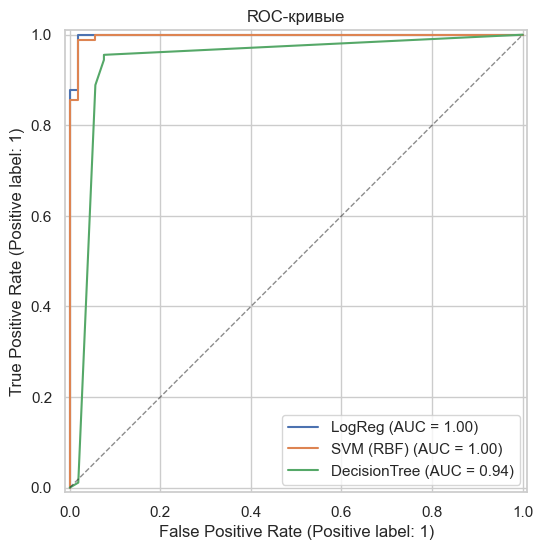

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_lr, name='LogReg', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_svm, name='SVM (RBF)', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_tree, name='DecisionTree', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_title('ROC-кривые')
plt.show()

**Наблюдения:**

* Логистическая регрессия и SVM показывают близкое качество (accuracy ≈ 0.97, ROC AUC ≈ 0.995). На этом датасете линейные/околилинейные методы работают почти идеально, потому что после стандартизации классы хорошо разделимы.
* Дерево решений с `max_depth=4` уступает: accuracy ≈ 0.93–0.95 и заметно более низкий ROC AUC. Дерево даёт ступенчатые вероятности (только несколько возможных значений), что и ограничивает площадь под ROC.
* Основная ошибка во всех трёх моделях — пропуск злокачественных опухолей (FN). Для медицинского применения это критичнее, чем ложные срабатывания, поэтому в реальной задаче порог принятия решения смещают.

## 5. Важность признаков в дереве решений

/var/folders/hx/f48x7vtn6dvfrw9ff07pmv400000gp/T/ipykernel_68253/584631855.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette='viridis', ax=ax)


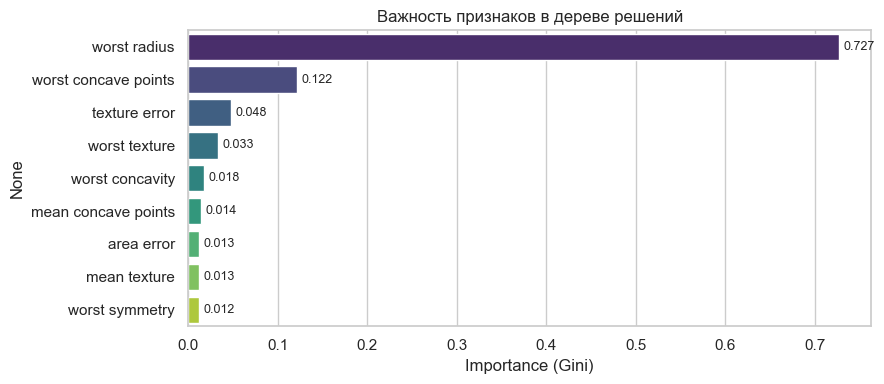

In [12]:
importances = pd.Series(tree.feature_importances_, index=FEATURES).sort_values(ascending=False)
top = importances[importances > 0]

fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(top))))
sns.barplot(x=top.values, y=top.index, palette='viridis', ax=ax)
ax.set_title('Важность признаков в дереве решений')
ax.set_xlabel('Importance (Gini)')
for i, v in enumerate(top.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Дерево с `max_depth=4` использует лишь небольшое подмножество признаков. Наибольший вклад в разбиение вносят характеристики, связанные с размером и формой опухоли (`worst radius`, `worst concave points`, `worst area`).

## 6. Визуализация дерева решений

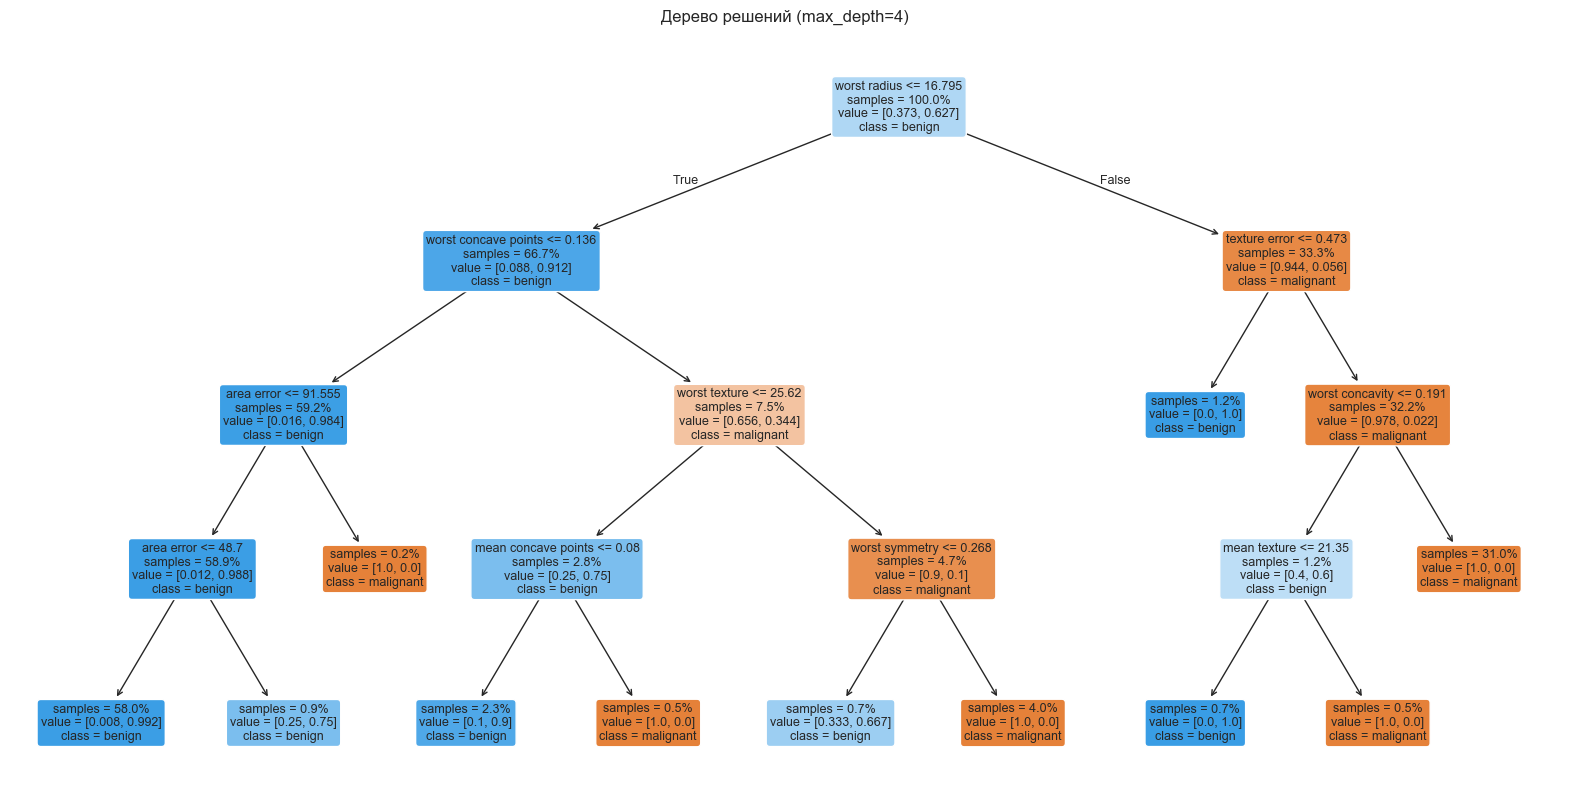

In [13]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=FEATURES,
    class_names=CLASSES,
    filled=True, rounded=True,
    impurity=False, proportion=True,
    fontsize=9, ax=ax
)
ax.set_title('Дерево решений (max_depth=4)')
plt.show()

### Правила дерева в текстовом виде

In [14]:
rules = export_text(tree, feature_names=FEATURES, max_depth=4, show_weights=True)
print(rules)

|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 91.56
|   |   |   |--- area error <= 48.70
|   |   |   |   |--- weights: [2.00, 245.00] class: 1
|   |   |   |--- area error >  48.70
|   |   |   |   |--- weights: [1.00, 3.00] class: 1
|   |   |--- area error >  91.56
|   |   |   |--- weights: [1.00, 0.00] class: 0
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.62
|   |   |   |--- mean concave points <= 0.08
|   |   |   |   |--- weights: [1.00, 9.00] class: 1
|   |   |   |--- mean concave points >  0.08
|   |   |   |   |--- weights: [2.00, 0.00] class: 0
|   |   |--- worst texture >  25.62
|   |   |   |--- worst symmetry <= 0.27
|   |   |   |   |--- weights: [1.00, 2.00] class: 1
|   |   |   |--- worst symmetry >  0.27
|   |   |   |   |--- weights: [17.00, 0.00] class: 0
|--- worst radius >  16.80
|   |--- texture error <= 0.47
|   |   |--- weights: [0.00, 5.00] class: 1
|   |--- texture error >  0.47
|   |   |--- worst 

## Итоги

1. На датасете Breast Cancer Wisconsin обучены три модели — логистическая регрессия, SVM с RBF-ядром и дерево решений (`max_depth=4`).
2. Качество оценено по двум метрикам — Accuracy и ROC AUC; дополнительно построены матрицы ошибок и ROC-кривые.
3. Лучшее качество демонстрируют LogReg и SVM (accuracy ≈ 0.97, ROC AUC ≈ 0.995) — на этом датасете классы хорошо разделимы линейными границами после стандартизации. Дерево решений с ограниченной глубиной слегка уступает, но даёт интерпретируемые правила.
4. Важность признаков в дереве показывает, что ключевые предикторы — характеристики размера и формы опухоли (`worst radius`, `worst concave points`, `worst area`).
5. Дерево решений визуализировано через `plot_tree` и выведено в текстовом виде через `export_text` — каждое правило легко прочитать и проверить вручную.
6. Главный практический вывод: даже на «удобном» датасете дерево уступает линейным методам по гладкости вероятностей, но выигрывает в интерпретируемости. Это типичный компромисс «качество vs объяснимость», который определяется требованиями задачи.